Calculating geometric intersections...


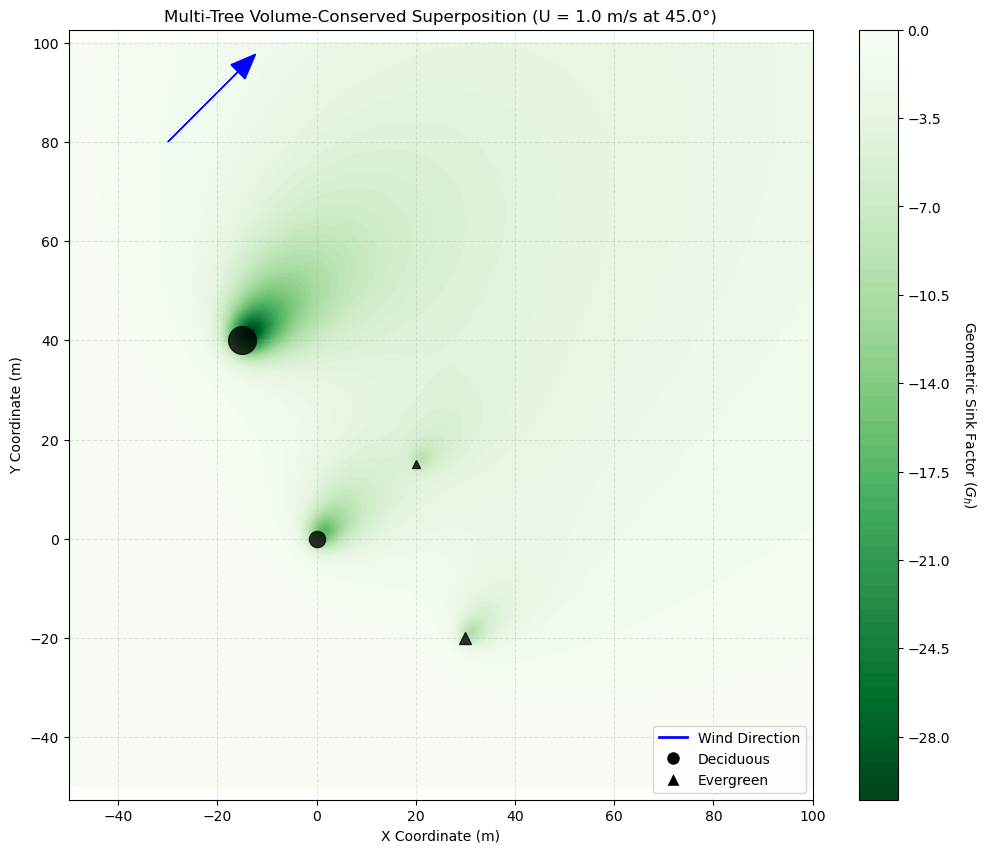

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Core Mathematical Functions
# ==========================================

def calculate_tree_volume(base_area, height, tree_type):
    """Calculates crown volume based on precise tree geometry."""
    if tree_type.lower() == 'deciduous':
        return base_area * height * (2/3)  # Ellipsoidal
    elif tree_type.lower() == 'evergreen':
        return base_area * height * (1/3)  # Conical
    else:
        raise ValueError("tree_type must be 'deciduous' or 'evergreen'")

def calculate_sigma_0(volume):
    """Converts a tree's crown volume (m^3) to the initial Gaussian dispersion parameter."""
    radius = (3 * volume / (4 * np.pi))**(1/3)
    return radius / 2.15

def calculate_spatial_geometric_sink(X, Y, trees, U, wind_dir_deg, T_max=600, D=0.2, max_distance=300):
    """
    Calculates the Geometric Sink Factor (G) with Dynamic Time-Stepping 
    to ensure continuity at high wind speeds.
    
    New Parameters:
    - max_distance: The maximum distance (in meters) from a tree to your furthest 
                    sensor or map edge. Used to cull unnecessary calculations at high wind.
    """
    theta = np.radians(wind_dir_deg)
    u_wind = U * np.cos(theta)
    v_wind = U * np.sin(theta)
    
    # 1. DYNAMIC TIME-STEPPING LOGIC
    # We want a maximum step distance of ~1 meter to ensure smooth overlapping.
    # If U = 10 m/s, dt = 0.1s. If U = 0.5 m/s, dt = 1.0s.
    dt = 1.0
    if U > 1.0:
        dt = 1.0 / U
        
    # 2. DYNAMIC T_MAX LOGIC
    # How long does it take the wind to blow the plume completely off the map?
    dynamic_T_max = T_max
    if U > 0.1:
        time_to_cross_map = max_distance / U
        # We take the minimum: either standard stagnation time, or time to cross map
        dynamic_T_max = min(T_max, time_to_cross_map)
        
    # Create the time array using our new dt
    # e.g., np.arange(0.1, 50.1, 0.1)
    t_array = np.arange(dt, dynamic_T_max + dt, dt)
    
    X_3d = X[..., np.newaxis]
    Y_3d = Y[..., np.newaxis]
    
    G_total_grid = np.zeros_like(X, dtype=float)
    
    for tree in trees:
        tx = tree['x']
        ty = tree['y']
        vol = calculate_tree_volume(tree['A'], tree['H'], tree['type'])
        sigma_0 = calculate_sigma_0(vol)
        
        # Calculate kinematics
        puff_x = tx + (u_wind * t_array)
        puff_y = ty + (v_wind * t_array)
        sigma_t = sigma_0 + (D * t_array)
        
        dist_sq = (X_3d - puff_x)**2 + (Y_3d - puff_y)**2
        
        # 3. MASS CONSERVED COEFFICIENT
        # We multiply the volume by dt so that summing all the fractions 
        # still equals the whole.
        coeff = (vol * dt) / (2 * np.pi * sigma_t**2)
        exponent = np.exp(-dist_sq / (2 * sigma_t**2))
        
        puffs_contrib = coeff * exponent 
        tree_grid = np.sum(puffs_contrib, axis=2)
        
        G_total_grid += tree_grid
        
    return G_total_grid

# ==========================================
# 2. Visualization Setup
# ==========================================

# Create the spatial grid
x_coords = np.linspace(-50, 100, 200)
y_coords = np.linspace(-50, 100, 200)
X, Y = np.meshgrid(x_coords, y_coords)

# Define the local forest using Base Area (A), Height (H), and Type
local_trees = [
    {'x': 0.0,   'y': 0.0,   'A': 20.0, 'H': 10.0, 'type': 'deciduous'},  # Center tree
    {'x': 20.0,  'y': 15.0,  'A': 10.0, 'H': 8.0,  'type': 'evergreen'},  # Smaller tree
    {'x': -15.0, 'y': 40.0,  'A': 30.0, 'H': 15.0, 'type': 'deciduous'},  # Massive tree
    {'x': 30.0,  'y': -20.0, 'A': 15.0, 'H': 12.0, 'type': 'evergreen'}   # Bottom right tree
]

# Define the specific hour's weather
WIND_SPEED = 1.0      # m/s
WIND_DIR = 45.0       # Blowing towards North-East
MAX_TIME = 600        # Integrate over 10 minutes of air
DIFFUSION = 0.5       # Plume spread rate

# ==========================================
# 3. Calculate and Plot
# ==========================================

print("Calculating geometric intersections...")
sink_map = calculate_spatial_geometric_sink(X, Y, local_trees, WIND_SPEED, WIND_DIR, MAX_TIME, DIFFUSION)

plt.figure(figsize=(12, 10))

# Plot the negative so it visualizes as a "sink" (depth)
contour = plt.contourf(X, Y, -sink_map, levels=60, cmap='Greens_r')
cbar = plt.colorbar(contour)
cbar.set_label('Geometric Sink Factor ($G_h$)', rotation=270, labelpad=20)

# Plot the trees 
for tree in local_trees:
    # Scale marker size slightly based on calculated volume for visual effect
    vol = calculate_tree_volume(tree['A'], tree['H'], tree['type'])
    marker_size = (vol / 20) + 5
    
    # Use different markers for evergreen vs deciduous
    marker_style = '^' if tree['type'] == 'evergreen' else 'o'
    plt.plot(tree['x'], tree['y'], marker=marker_style, color='black', markersize=marker_size, alpha=0.8)

# Draw Wind Arrow
arrow_length = 20
plt.arrow(-30, 80, 
          arrow_length * np.cos(np.radians(WIND_DIR)), 
          arrow_length * np.sin(np.radians(WIND_DIR)), 
          head_width=4, head_length=5, fc='blue', ec='blue', label='Wind Direction')

plt.title(f'Multi-Tree Volume-Conserved Superposition (U = {WIND_SPEED} m/s at {WIND_DIR}°)')
plt.xlabel('X Coordinate (m)')
plt.ylabel('Y Coordinate (m)')

# Add custom legend entries for the tree shapes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Wind Direction'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Deciduous'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markersize=10, label='Evergreen')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.show()

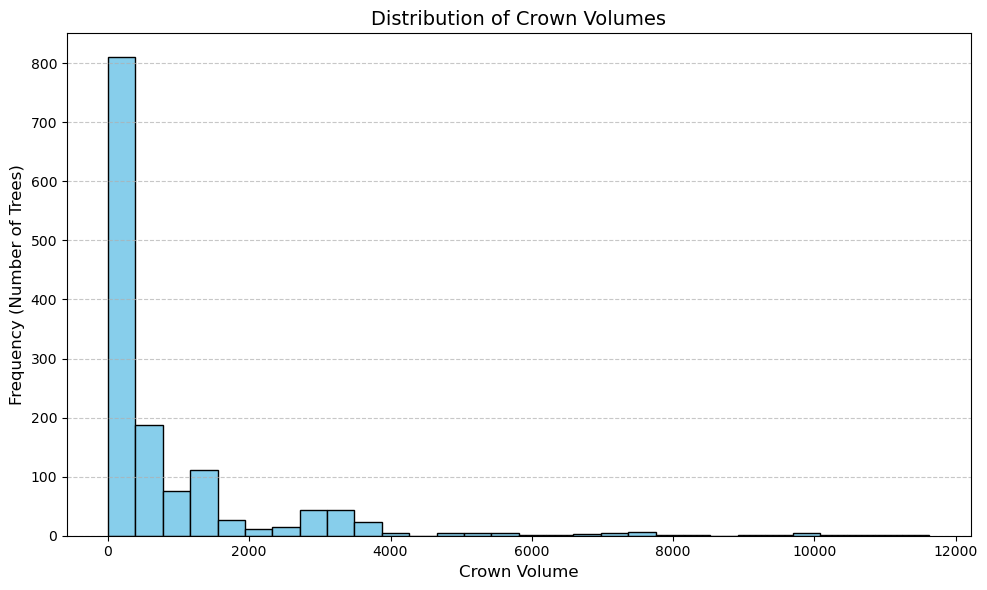

In [6]:
import pandas as pd

# Load the dataset
vol_csv = pd.read_csv('VOLUME_DATASET.csv')

# Find the maximum value in the CROWN_VOLUME column
vol_csv = pd.read_csv('VOLUME_DATASET.csv')

# 2. Extract the column (dropping any missing values so they don't break the plot)
crown_volumes = vol_csv['CROWN_VOLUME'].dropna()

# 3. Set up the figure size
plt.figure(figsize=(10, 6))

# 4. Create the histogram
# 'bins' controls how many bars the data is grouped into. You can adjust this number.
plt.hist(crown_volumes, bins=30, color='skyblue', edgecolor='black')

# 5. Add titles and labels to make it readable
plt.title('Distribution of Crown Volumes', fontsize=14)
plt.xlabel('Crown Volume', fontsize=12)
plt.ylabel('Frequency (Number of Trees)', fontsize=12)

# Optional: add a faint grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Show the plot
plt.tight_layout()
plt.show()




In [7]:
import pandas as pd

# Load the dataset
vol_csv = pd.read_csv('VOLUME_DATASET.csv')

# Find the maximum value in the CROWN_VOLUME column
biggest_volume = vol_csv['CROWN_VOLUME'].max()

print(f"The biggest CROWN_VOLUME is: {biggest_volume}")

The biggest CROWN_VOLUME is: 11628.1


In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar

def calculate_sigma_0(volume):
    """Calculates initial dispersion spread based on volume."""
    radius = (3 * volume / (4 * np.pi))**(1/3)
    return radius / 2.15

def get_stagnant_decay_ratio(D, volume, target_radius, T_max=900):
    """
    Calculates the ratio of concentration at 'target_radius' vs the center
    for a given Diffusion Rate (D) under stagnant (U=0) conditions.
    """
    sigma_0 = calculate_sigma_0(volume)
    t_array = np.arange(1, T_max + 1)
    
    # Puff sizes over time
    sigma_t = sigma_0 + (D * t_array)
    
    # Calculate Center Concentration (Distance = 0)
    coeff = volume / (2 * np.pi * sigma_t**2)
    center_puffs = coeff * np.exp(0) # e^0 is 1
    center_sum = np.sum(center_puffs)
    
    # Calculate Edge Concentration (Distance = target_radius)
    edge_puffs = coeff * np.exp(-(target_radius**2) / (2 * sigma_t**2))
    edge_sum = np.sum(edge_puffs)
    
    return edge_sum / center_sum

def optimize_diffusion_rate(volume, target_radius=6.0, target_decay_ratio=0.05, T_max=900):
    """
    Finds the exact Diffusion Rate (D) that makes the plume decay to the 
    target ratio (e.g., 5%) at the target radius (e.g., 6m).
    """
    # Objective function: We want the difference between our current ratio 
    # and our target ratio to be exactly 0.
    def objective_function(D):
        current_ratio = get_stagnant_decay_ratio(D, volume, target_radius, T_max)
        # We square the error to ensure the optimizer finds an absolute minimum
        return (current_ratio - target_decay_ratio)**2

    # Run the optimizer searching for D between 0.01 and 2.0 m/s
    result = minimize_scalar(objective_function, bounds=(0.01, 2.0), method='bounded')
    
    if result.success:
        optimal_D = result.x
        actual_ratio = get_stagnant_decay_ratio(optimal_D, volume, target_radius, T_max)
        print(f"Optimization Successful!")
        print(f"Optimal Diffusion Rate (D): {optimal_D:.4f} m/s")
        print(f"Verification: Decay at {target_radius}m is {actual_ratio*100:.2f}% of center.")
        return optimal_D
    else:
        raise ValueError("Optimizer failed to find a valid Diffusion Rate.")

# ==========================================
# Run the Optimizer
# ==========================================

# 1. Define your "Average" or "Representative" tree to lock in your physics
REFERENCE_VOLUME = 3000.0  # m^3
EMPIRICAL_RADIUS = np.sqrt(REFERENCE_VOLUME / np.pi) + 6.0    # meters (from your literature)
DECAY_THRESHOLD = 0.05    # 5% (Standard scientific definition of a plume "edge")

# 2. Find your golden D parameter
tuned_D = optimize_diffusion_rate(
    volume=REFERENCE_VOLUME, 
    target_radius=EMPIRICAL_RADIUS, 
    target_decay_ratio=DECAY_THRESHOLD, 
    T_max=900
)

# You now pass `tuned_D` into the D parameter of your `calculate_spatial_geometric_sink` 
# function for all your real dataset hourly calculations!

Optimization Successful!
Optimal Diffusion Rate (D): 0.0359 m/s
Verification: Decay at 36.90193616185517m is 5.00% of center.
